# Football Player Scouting & Recruitment Recommendation System

## 1. Data Cleaning & Exploratory Data Analysis

This notebook introduces and explores the FC27 player dataset used for the football scouting recommendation system.

The objectives are to:

- understand the structure and quality of the dataset
- identify missing values and duplicates
- clean irrelevant or unusable features
- analyze player positions, clubs, leagues and demographics
- investigate the distribution of player attributes
- identify patterns that will inform the feature engineering and recommendation system

> **Dataset limitation:** The dataset contains FC27 in-game player attributes. Therefore, the resulting recommendations represent similarity and suitability according to game attributes, rather than objective real-world scouting or player performance.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Allow imports from the project root
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.preprocessing import load_data, clean_data, add_age

## 1. Load the raw dataset

In [2]:
DATA_PATH = PROJECT_ROOT / "Data" / "players.csv"

df_raw = load_data(DATA_PATH)

print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (19789, 60)


,player_id,common_name,first_name,last_name,overall_rating,position,alternate_positions,club,league,nationality,...,defending_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,edition,snapshot_date
0,227203,Alexia Putellas,Alexia,Putellas Segura,91,CM,CAM ST,London City,Barclays WSL,Spain,...,60,82,64,15,17,11,15,10,fc27,2026-09-12
1,231747,NaN,Kylian,Mbappé,91,ST,LW,Real Madrid,LALIGA EA SPORTS,France,...,15,34,24,13,5,7,11,6,fc27,2026-09-12
2,239085,NaN,Erling,Haaland,91,ST,NaN,Manchester City,Premier League,Norway,...,42,47,33,7,14,13,11,7,fc27,2026-09-12
3,192119,NaN,Thibaut,Courtois,90,GK,NaN,Real Madrid,LALIGA EA SPORTS,Belgium,...,20,18,16,87,89,78,90,90,fc27,2026-09-12
4,202126,NaN,Harry,Kane,90,ST,NaN,FC Bayern München,Bundesliga,England,...,46,44,42,8,10,11,14,11,fc27,2026-09-12


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19789 entries, 0 to 19788
Data columns (total 60 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   player_id                   19789 non-null  int64         
 1   common_name                 2879 non-null   object        
 2   first_name                  19789 non-null  object        
 3   last_name                   19789 non-null  object        
 4   overall_rating              19789 non-null  int64         
 5   position                    19789 non-null  object        
 6   alternate_positions         12896 non-null  object        
 7   club                        19789 non-null  object        
 8   league                      19789 non-null  object        
 9   nationality                 19789 non-null  object        
 10  gender                      19789 non-null  object        
 11  preferred_foot              19789 non-null  object    

The dataset contains 19,789 players and 60 features describing player identity, position, club, league, demographics and in-game attributes.

In [4]:
df_raw.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
player_id,19789.0,NaN,NaN,NaN,197363.190459,20801.0,85727.0,236699.0,262088.0,279948.0,80201.668199
common_name,2879,2817,Paulinho,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
first_name,19789,7294,Daniel,132,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_name,19789,14971,Kim,85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
overall_rating,19789.0,NaN,NaN,NaN,66.723281,47.0,62.0,67.0,71.0,91.0,6.959486
position,19789,12,CB,3595,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alternate_positions,12896,541,CM,1468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
club,19789,702,Chelsea,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN
league,19789,63,LPF,870,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nationality,19789,164,England,1527,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Check data quality

Before cleaning the dataset, we check:

- duplicate rows
- duplicate player IDs
- missing values
- unique values in categorical columns

In [5]:
print("Duplicate rows:", df_raw.duplicated().sum())
print("Duplicate player IDs:", df_raw["player_id"].duplicated().sum())

missing = (
    df_raw.isna()
    .sum()
    .sort_values(ascending=False)
)

missing[missing > 0]

Duplicate rows: 0
Duplicate player IDs: 0


height_cm              19789
weight_kg              19789
common_name            16910
playstyles             11738
alternate_positions     6893
dtype: int64

## 3. Clean the dataset

Some columns are not useful for the scouting system:

- `common_name`: largely redundant with first/last name
- `height_cm` and `weight_kg`: entirely missing
- `edition`: constant
- `snapshot_date`: constant

The cleaning logic is implemented in `src.preprocessing` so that the same
logic can be reused by the Streamlit application and other notebooks.

In [6]:
df = clean_data(df_raw)

## 4. Player eligibility

A player can have:

- a primary position
- zero or more alternate positions

We combine these into `eligible_positions` so that a player can be
considered when recruiting for an alternate position.

In [7]:
df["eligible_positions"] = (
    df["position"]
    + " "
    + df["alternate_positions"].fillna("")
).str.strip()

df[
    ["first_name", "last_name", "position",
     "alternate_positions", "eligible_positions"]
].head(10)

,first_name,last_name,position,alternate_positions,eligible_positions
0,Alexia,Putellas Segura,CM,CAM ST,CM CAM ST
1,Kylian,Mbappé,ST,LW,ST LW
2,Erling,Haaland,ST,NaN,ST
3,Thibaut,Courtois,GK,NaN,GK
4,Harry,Kane,ST,NaN,ST
5,Ousmane,Dembélé,ST,RW CAM RM,ST RW CAM RM
6,Rodrigo,Hernández Cascante,CDM,CM,CDM CM
7,Aitana,Bonmatí Conca,CM,CAM,CM CAM
8,Khadija,Shaw,ST,NaN,ST
9,Michael,Olise,RM,RW CAM,RM RW CAM


In [8]:
print(f"Shape after cleaning: {df.shape}")
df.head()

Shape after cleaning: (19789, 56)


,player_id,first_name,last_name,overall_rating,position,alternate_positions,club,league,nationality,gender,...,mentality_composure,defending_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,eligible_positions
0,227203,Alexia,Putellas Segura,91,CM,CAM ST,London City,Barclays WSL,Spain,Women's Football,...,92,60,82,64,15,17,11,15,10,CM CAM ST
1,231747,Kylian,Mbappé,91,ST,LW,Real Madrid,LALIGA EA SPORTS,France,Men's Football,...,88,15,34,24,13,5,7,11,6,ST LW
2,239085,Erling,Haaland,91,ST,NaN,Manchester City,Premier League,Norway,Men's Football,...,86,42,47,33,7,14,13,11,7,ST
3,192119,Thibaut,Courtois,90,GK,NaN,Real Madrid,LALIGA EA SPORTS,Belgium,Men's Football,...,66,20,18,16,87,89,78,90,90,GK
4,202126,Harry,Kane,90,ST,NaN,FC Bayern München,Bundesliga,England,Men's Football,...,92,46,44,42,8,10,11,14,11,ST


## 5. Position distribution

In [9]:
position_counts = (
    df["position"]
    .value_counts()
    .sort_values(ascending=False)
)

position_counts

position
CB     3595
ST     2718
CM     2376
GK     2204
CDM    1568
RB     1531
LB     1435
CAM    1163
LM     1149
RM     1077
LW      489
RW      484
Name: count, dtype: int64

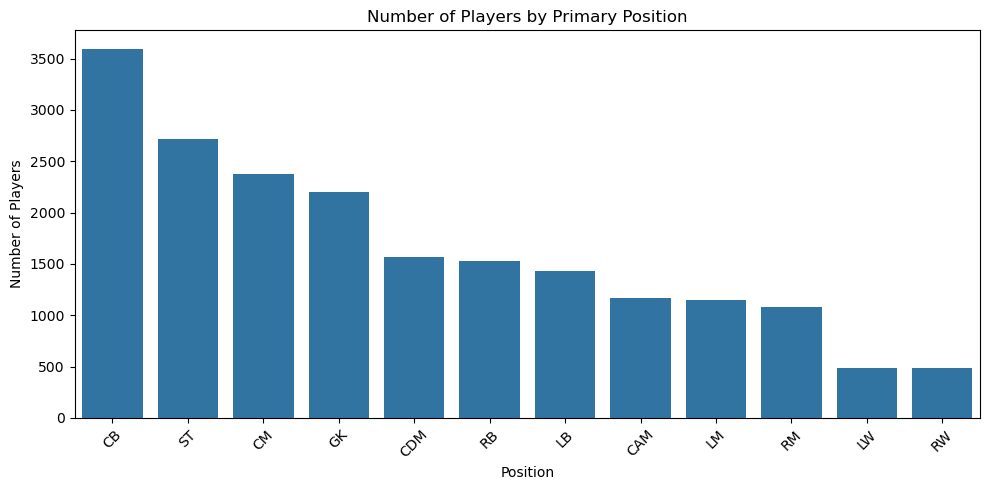

In [10]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=position_counts.index,
    y=position_counts.values
)

plt.title("Number of Players by Primary Position")
plt.xlabel("Position")
plt.ylabel("Number of Players")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The dataset contains a substantial number of players across all 12
primary positions.

The distribution is not balanced. Centre-backs and strikers have much
larger populations than some wide positions such as LW and RW.

This imbalance is important when interpreting position-based analysis.

## 6. Clubs and leagues

In [11]:
print("Unique clubs:", df["club"].nunique())
print("Unique leagues:", df["league"].nunique())

Unique clubs: 702
Unique leagues: 63


In [12]:
df["club"].value_counts().head(15)

club
Chelsea            65
1. FC Köln         65
Spurs              63
VfL Wolfsburg      62
VfB Stuttgart      62
Brighton           60
Union Berlin       60
Liverpool          59
Slavia Praha       59
SC Freiburg        58
Aston Villa        58
Athletic Club      58
1. FSV Mainz 05    58
Frankfurt          57
FC Twente          56
Name: count, dtype: int64

In [13]:
df["league"].value_counts().head(15)

league
LPF                   870
MLS                   806
EFL Championship      669
Premier League        612
EFL League One        612
EFL League Two        605
Serie A Enilive       578
Bundesliga            548
LALIGA EA SPORTS      548
3. Liga               537
ROSHN Saudi League    520
LALIGA HYPERMOTION    513
1A Pro League         502
Ligue 1 McDonald's    500
Bundesliga 2          499
Name: count, dtype: int64

## 7. Gender distribution

In [14]:
df["gender"].value_counts()

gender
Men's Football      17849
Women's Football     1940
Name: count, dtype: int64

In [15]:
pd.crosstab(
    df["gender"],
    df["position"]
)

position,CAM,CB,CDM,CM,GK,LB,LM,LW,RB,RM,RW,ST
gender,,,,,,,,,,,,
Men's Football,1068,3256,1456,2095,1971,1289,1042,455,1375,974,450,2418
Women's Football,95,339,112,281,233,146,107,34,156,103,34,300


## 8. Player age

The original `birthdate` column is retained because it is the source of
truth.

For this analysis, we derive age using the dataset snapshot date as the
reference date.

In [16]:
REFERENCE_DATE = pd.Timestamp("2026-09-12")

df = add_age(
    df,
    reference_date=REFERENCE_DATE
)

df["age"].describe()

count    19789.000000
mean        25.444843
std          4.665012
min         16.000000
25%         22.000000
50%         25.000000
75%         29.000000
max         42.000000
Name: age, dtype: float64

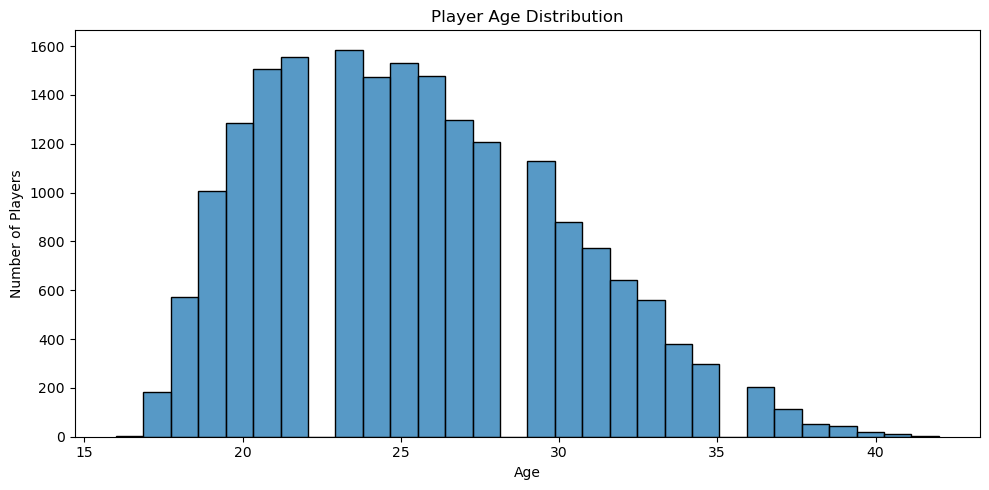

In [17]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="age",
    bins=30
)

plt.title("Player Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Players")
plt.tight_layout()
plt.show()

## 9. Overall rating by position

Overall rating is useful for exploratory analysis, but it will **not**
be used in our custom scouting score.

Using overall rating directly would largely reproduce EA's own aggregate
rating rather than creating an independent recruitment methodology.

In [18]:
overall_by_position = (
    df.groupby("position")["overall_rating"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

overall_by_position

,count,mean,median,min,max
position,,,,,
CDM,1568,67.602041,68.0,47,90
CAM,1163,67.568358,67.0,47,90
LM,1149,67.174064,67.0,48,89
CB,3595,67.129903,67.0,47,89
RM,1077,67.051068,67.0,47,90
LW,489,67.047035,67.0,47,89
LB,1435,66.700348,67.0,49,89
ST,2718,66.605592,66.0,47,91
CM,2376,66.575337,67.0,47,91


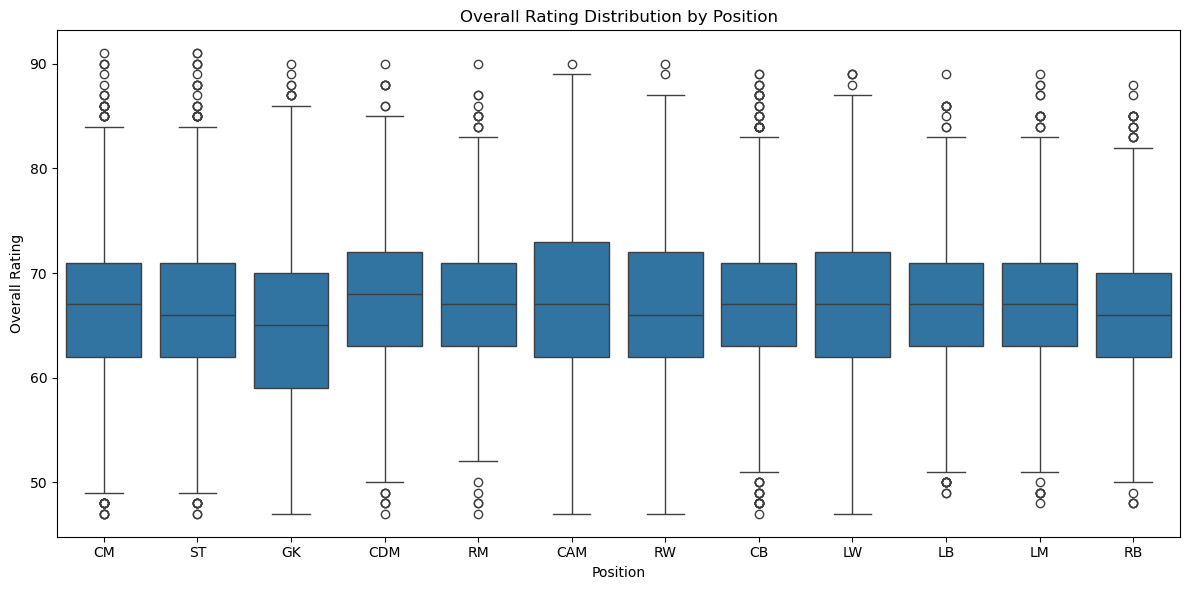

In [19]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="position",
    y="overall_rating"
)

plt.title("Overall Rating Distribution by Position")
plt.xlabel("Position")
plt.ylabel("Overall Rating")
plt.tight_layout()
plt.show()

## 10. Attribute profiles by position

The core of the scouting system is understanding how player attributes
differ between positions.

We therefore calculate the average broad attributes for each position.

In [20]:
broad_attributes = [
    "pace",
    "shooting",
    "passing",
    "dribbling",
    "defending",
    "physicality"
]

position_attribute_means = (
    df.groupby("position")[broad_attributes]
    .mean()
    .round(2)
)

position_attribute_means

,pace,shooting,passing,dribbling,defending,physicality
position,,,,,,
CAM,69.81,62.73,65.46,69.50,45.39,58.35
CB,60.60,36.94,51.03,54.21,66.94,71.60
CDM,62.18,53.21,62.41,64.73,64.79,68.68
CM,65.79,59.11,64.67,67.39,59.51,64.51
GK,65.28,63.57,62.79,66.16,34.38,64.03
LB,72.64,47.33,59.52,64.01,62.55,64.89
LM,77.14,61.34,61.83,68.68,40.26,58.51
LW,77.33,63.12,61.33,69.12,34.66,57.11
RB,72.67,46.62,58.60,63.34,62.51,65.36


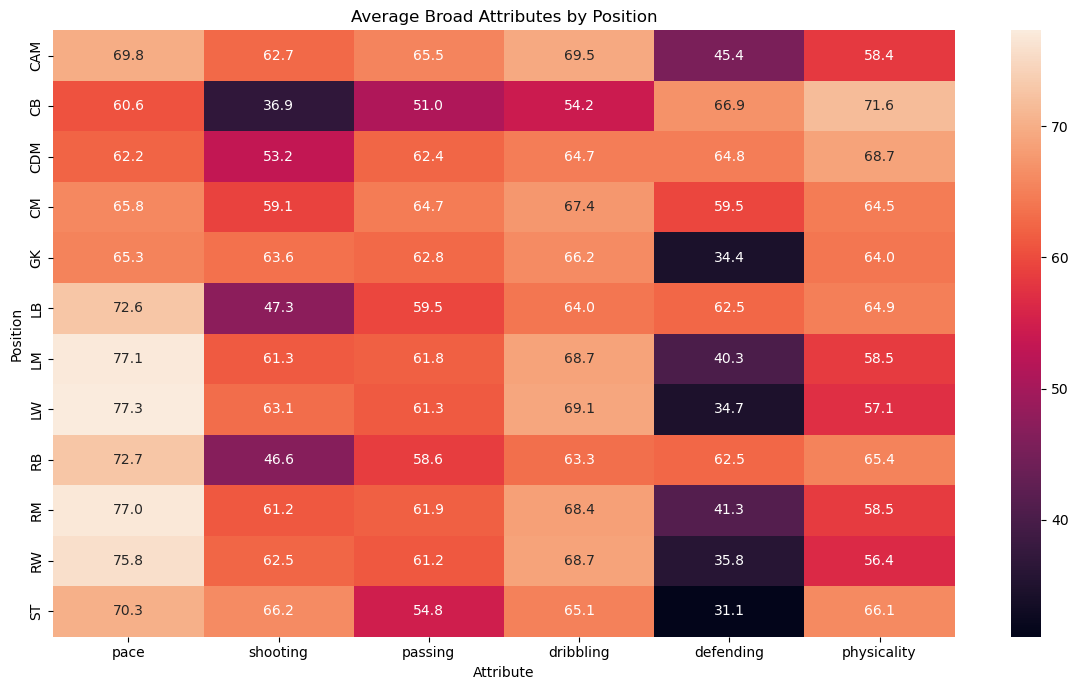

In [21]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    position_attribute_means,
    annot=True,
    fmt=".1f"
)

plt.title("Average Broad Attributes by Position")
plt.xlabel("Attribute")
plt.ylabel("Position")
plt.tight_layout()
plt.show()

## 11. Detailed attribute analysis

The broad EA attributes are useful for exploration, but the recommendation
system will use more specific attributes.

For example:

- acceleration + sprint speed → pace
- standing + sliding tackle → tackling
- awareness + interceptions → defending
- short + long passing → passing technique
- strength + stamina → physical profile

These combinations are handled centrally in `src.features`.

In [22]:
from src.features import (
    SCOUTING_ATTRIBUTES,
    ABILITY_GROUPS,
    INDIVIDUAL_ABILITIES,
    normalize_attributes,
    create_ability_features,
)

In [23]:
df_normalized = normalize_attributes(df)
df_normalized = create_ability_features(df_normalized)

print("Number of scouting attributes:", len(SCOUTING_ATTRIBUTES))
print("Number of ability features:", len(
    list(ABILITY_GROUPS.keys())
    + INDIVIDUAL_ABILITIES
    + ["stamina"]
))

Number of scouting attributes: 36
Number of ability features: 23


In [24]:
ability_features = (
    list(ABILITY_GROUPS.keys())
    + INDIVIDUAL_ABILITIES
    + ["stamina"]
)

position_ability_means = (
    df_normalized
    .groupby("position")[ability_features]
    .mean()
    .round(3)
)

position_ability_means

,pace,dribbling_control,agility,passing_technique,shooting_power,defending,tackling,aerial,physical,attacking_finishing,...,mentality_positioning,mentality_composure,movement_reactions,mentality_aggression,skill_moves,weak_foot,mentality_penalties,skill_curve,skill_fk_accuracy,stamina
position,,,,,,,,,,,,,,,,,,,,,
CAM,0.669,0.713,0.714,0.671,0.620,0.447,0.449,0.484,0.525,0.641,...,0.670,0.628,0.535,0.513,0.534,0.545,0.573,0.633,0.589,0.622
CB,0.554,0.539,0.468,0.575,0.355,0.712,0.707,0.688,0.675,0.313,...,0.370,0.551,0.523,0.669,0.259,0.441,0.371,0.359,0.312,0.634
CDM,0.576,0.663,0.616,0.676,0.551,0.699,0.687,0.581,0.649,0.501,...,0.566,0.604,0.548,0.678,0.338,0.499,0.479,0.529,0.487,0.704
CM,0.620,0.692,0.666,0.687,0.597,0.631,0.628,0.526,0.604,0.587,...,0.646,0.609,0.551,0.611,0.404,0.515,0.515,0.579,0.543,0.694
GK,0.237,0.104,0.247,0.204,0.210,0.086,0.065,0.241,0.306,0.062,...,0.063,0.294,0.459,0.162,0.000,0.372,0.090,0.070,0.074,0.160
LB,0.703,0.645,0.658,0.588,0.461,0.667,0.669,0.577,0.608,0.441,...,0.573,0.549,0.512,0.606,0.354,0.448,0.416,0.566,0.452,0.692
LM,0.758,0.699,0.732,0.602,0.597,0.382,0.380,0.507,0.537,0.633,...,0.654,0.584,0.501,0.472,0.536,0.530,0.552,0.602,0.522,0.630
LW,0.760,0.708,0.719,0.587,0.617,0.308,0.309,0.501,0.517,0.655,...,0.659,0.586,0.487,0.440,0.538,0.542,0.567,0.604,0.518,0.597
RB,0.703,0.637,0.653,0.582,0.444,0.665,0.669,0.581,0.613,0.439,...,0.567,0.548,0.508,0.613,0.342,0.484,0.414,0.537,0.408,0.693


## 12. Position profiles

The normalized ability profiles provide a more detailed view of the
characteristics associated with each position.

These profiles will later help us construct transparent, position-specific
scouting weights.

The weights themselves are not learned from this analysis. They combine
football logic with the observed characteristics of each position.

In [33]:
position_ability_means.T

position,CAM,CB,CDM,CM,GK,LB,LM,LW,RB,RM,RW,ST
pace,0.669,0.554,0.576,0.620,0.237,0.703,0.758,0.760,0.703,0.756,0.742,0.673
dribbling_control,0.713,0.539,0.663,0.692,0.104,0.645,0.699,0.708,0.637,0.695,0.702,0.668
agility,0.714,0.468,0.616,0.666,0.247,0.658,0.732,0.719,0.653,0.731,0.716,0.602
passing_technique,0.671,0.575,0.676,0.687,0.204,0.588,0.602,0.587,0.582,0.601,0.589,0.529
shooting_power,0.620,0.355,0.551,0.597,0.210,0.461,0.597,0.617,0.444,0.596,0.607,0.639
defending,0.447,0.712,0.699,0.631,0.086,0.667,0.382,0.308,0.665,0.398,0.323,0.250
tackling,0.449,0.707,0.687,0.628,0.065,0.669,0.380,0.309,0.669,0.392,0.323,0.225
aerial,0.484,0.688,0.581,0.526,0.241,0.577,0.507,0.501,0.581,0.499,0.481,0.685
physical,0.525,0.675,0.649,0.604,0.306,0.608,0.537,0.517,0.613,0.534,0.506,0.626
attacking_finishing,0.641,0.313,0.501,0.587,0.062,0.441,0.633,0.655,0.439,0.631,0.650,0.696


## 13. Playstyles

Playstyles are treated separately from the numerical player profile.

The dataset contains both base and `+` versions of playstyles. For
example:

- `Intercept`
- `Intercept+`

The recommendation system considers the `+` version an enhanced match.

Missing playstyles are retained rather than interpreted as a numerical
zero-valued football ability.

In [28]:
from src.features import prepare_playstyles

df_normalized = prepare_playstyles(df_normalized)

In [29]:
df_normalized[
    [
        "first_name",
        "last_name",
        "playstyles",
        "playstyle_list",
        "base_playstyles"
    ]
].head(10)

,first_name,last_name,playstyles,playstyle_list,base_playstyles
0,Alexia,Putellas Segura,"Finesse Shot, Gamechanger, Tiki Taka, Inventiv...","[Finesse Shot, Gamechanger, Tiki Taka, Inventi...","[Finesse Shot, Gamechanger, Tiki Taka, Inventi..."
1,Kylian,Mbappé,"Finesse Shot, Acrobatic, Low Driven Shot, Game...","[Finesse Shot, Acrobatic, Low Driven Shot, Gam...","[Finesse Shot, Acrobatic, Low Driven Shot, Gam..."
2,Erling,Haaland,"Chip Shot, Power Shot, Precision Header, Acrob...","[Chip Shot, Power Shot, Precision Header, Acro...","[Chip Shot, Power Shot, Precision Header, Acro..."
3,Thibaut,Courtois,"Far Throw, Far Reach, Rush Out+","[Far Throw, Far Reach, Rush Out+]","[Far Throw, Far Reach, Rush Out]"
4,Harry,Kane,"Precision Header, Low Driven Shot, Gamechanger...","[Precision Header, Low Driven Shot, Gamechange...","[Precision Header, Low Driven Shot, Gamechange..."
5,Ousmane,Dembélé,"Low Driven Shot, Gamechanger, Inventive, Rapid...","[Low Driven Shot, Gamechanger, Inventive, Rapi...","[Low Driven Shot, Gamechanger, Inventive, Rapi..."
6,Rodrigo,Hernández Cascante,"Power Shot, Aerial Fortress, Press Proven, Bru...","[Power Shot, Aerial Fortress, Press Proven, Br...","[Power Shot, Aerial Fortress, Press Proven, Br..."
7,Aitana,Bonmatí Conca,"Incisive Pass, Tiki Taka, Inventive, Technical...","[Incisive Pass, Tiki Taka, Inventive, Technica...","[Incisive Pass, Tiki Taka, Inventive, Technica..."
8,Khadija,Shaw,"Precision Header, Low Driven Shot, Press Prove...","[Precision Header, Low Driven Shot, Press Prov...","[Precision Header, Low Driven Shot, Press Prov..."
9,Michael,Olise,"Finesse Shot, Incisive Pass, Tiki Taka, Whippe...","[Finesse Shot, Incisive Pass, Tiki Taka, Whipp...","[Finesse Shot, Incisive Pass, Tiki Taka, Whipp..."


In [30]:
playstyle_counts = {}

for styles in df_normalized["playstyle_list"]:
    for style in styles:
        playstyle_counts[style] = playstyle_counts.get(style, 0) + 1

playstyle_counts = (
    pd.Series(playstyle_counts)
    .sort_values(ascending=False)
)

playstyle_counts.head(20)

Aerial Fortress     1193
Technical           1052
Long Ball Pass      1034
Intercept            853
Rapid                840
Precision Header     708
Finesse Shot         598
Slide Tackle         552
Whipped Pass         540
Quick Step           531
Incisive Pass        529
Anticipate           511
Relentless           506
Block                502
Bruiser              494
Jockey               494
Press Proven         489
Long Throw           437
Inventive            432
First Touch          415
dtype: int64

In [7]:
df.isna().sum().sort_values(ascending=False).head(10)

playstyles             11738
alternate_positions     6893
last_name                  0
player_id                  0
overall_rating             0
position                   0
club                       0
first_name                 0
league                     0
nationality                0
dtype: int64

## 14. Final dataset summary

At this point we have:

- cleaned player records
- player eligibility information
- derived age
- normalized scouting attributes
- position-level ability features
- parsed playstyles

The following notebooks will build the actual recruitment recommendation
system on top of this prepared data.

In [31]:
print("Final rows:", len(df_normalized))
print("Final columns:", len(df_normalized.columns))
print("Positions:", df_normalized["position"].nunique())
print("Clubs:", df_normalized["club"].nunique())
print("Leagues:", df_normalized["league"].nunique())

Final rows: 19789
Final columns: 67
Positions: 12
Clubs: 702
Leagues: 63


In [32]:
df_normalized.head()

,player_id,first_name,last_name,overall_rating,position,alternate_positions,club,league,nationality,gender,...,dribbling_control,agility,passing_technique,shooting_power,tackling,aerial,physical,stamina,playstyle_list,base_playstyles
0,227203,Alexia,Putellas Segura,91,CM,CAM ST,London City,Barclays WSL,Spain,Women's Football,...,0.977778,0.926387,0.975904,0.937528,0.776758,0.789469,0.749534,0.8125,"[Finesse Shot, Gamechanger, Tiki Taka, Inventi...","[Finesse Shot, Gamechanger, Tiki Taka, Inventi..."
1,231747,Kylian,Mbappé,91,ST,LW,Real Madrid,LALIGA EA SPORTS,France,Men's Football,...,0.977451,0.901138,0.836308,0.928390,0.250502,0.871281,0.790672,0.8500,"[Finesse Shot, Acrobatic, Low Driven Shot, Gam...","[Finesse Shot, Acrobatic, Low Driven Shot, Gam..."
2,239085,Erling,Haaland,91,ST,NaN,Manchester City,Premier League,Norway,Men's Football,...,0.846405,0.633179,0.732560,0.931536,0.381851,0.933570,0.891325,0.8125,"[Chip Shot, Power Shot, Precision Header, Acro...","[Chip Shot, Power Shot, Precision Header, Acro..."
3,192119,Thibaut,Courtois,90,GK,NaN,Real Madrid,LALIGA EA SPORTS,Belgium,Men's Football,...,0.126797,0.455014,0.268035,0.327416,0.107604,0.335953,0.457183,0.2875,"[Far Throw, Far Reach, Rush Out+]","[Far Throw, Far Reach, Rush Out]"
4,202126,Harry,Kane,90,ST,NaN,FC Bayern München,Bundesliga,England,Men's Football,...,0.875490,0.659673,0.878328,0.963146,0.419082,0.912441,0.821549,0.7625,"[Precision Header, Low Driven Shot, Gamechange...","[Precision Header, Low Driven Shot, Gamechange..."


## 15. Save the cleaned dataset

The cleaned dataset is saved so that subsequent notebooks can start from
the same consistent data without repeating the raw-data cleaning steps.

Feature normalization and scouting-specific feature construction are not
saved here because they are handled by the reusable functions in `src/`.

In [33]:
CLEANED_DATA_PATH = PROJECT_ROOT / "Data" / "players_cleaned.csv"

df.to_csv(CLEANED_DATA_PATH, index=False)

print(f"Saved cleaned dataset to: {CLEANED_DATA_PATH}")
print(f"Shape: {df.shape}")

Saved cleaned dataset to: c:\Users\DELL\Documents\Scouting project\Data\players_cleaned.csv
Shape: (19789, 57)
